In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/diagnosed_cbc_data_v4.csv')
df.head()

,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT,Diagnosis
0,10.0,43.2,50.1,4.3,5.0,2.77,7.3,24.2,87.7,26.3,30.1,189.0,12.5,0.17,Normocytic hypochromic anemia
1,10.0,42.4,52.3,4.2,5.3,2.84,7.3,25.0,88.2,25.7,20.2,180.0,12.5,0.16,Normocytic hypochromic anemia
2,7.2,30.7,60.7,2.2,4.4,3.97,9.0,30.5,77.0,22.6,29.5,148.0,14.3,0.14,Iron deficiency anemia
3,6.0,30.2,63.5,1.8,3.8,4.22,3.8,32.8,77.9,23.2,29.8,143.0,11.3,0.12,Iron deficiency anemia
4,4.2,39.1,53.7,1.6,2.3,3.93,0.4,316.0,80.6,23.9,29.7,236.0,12.8,0.22,Normocytic hypochromic anemia


In [2]:
df.shape

(1281, 15)

In [3]:
df.columns.tolist()

['WBC',
 'LYMp',
 'NEUTp',
 'LYMn',
 'NEUTn',
 'RBC',
 'HGB',
 'HCT',
 'MCV',
 'MCH',
 'MCHC',
 'PLT',
 'PDW',
 'PCT',
 'Diagnosis']

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1281 entries, 0 to 1280
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   WBC        1281 non-null   float64
 1   LYMp       1281 non-null   float64
 2   NEUTp      1281 non-null   float64
 3   LYMn       1281 non-null   float64
 4   NEUTn      1281 non-null   float64
 5   RBC        1281 non-null   float64
 6   HGB        1281 non-null   float64
 7   HCT        1281 non-null   float64
 8   MCV        1281 non-null   float64
 9   MCH        1281 non-null   float64
 10  MCHC       1281 non-null   float64
 11  PLT        1281 non-null   float64
 12  PDW        1281 non-null   float64
 13  PCT        1281 non-null   float64
 14  Diagnosis  1281 non-null   str    
dtypes: float64(14), str(1)
memory usage: 175.8 KB


In [5]:
df['Diagnosis'].value_counts()

Diagnosis
Healthy                           336
Normocytic hypochromic anemia     279
Normocytic normochromic anemia    269
Iron deficiency anemia            189
Thrombocytopenia                   73
Other microcytic anemia            59
Leukemia                           47
Macrocytic anemia                  18
Leukemia with thrombocytopenia     11
Name: count, dtype: int64

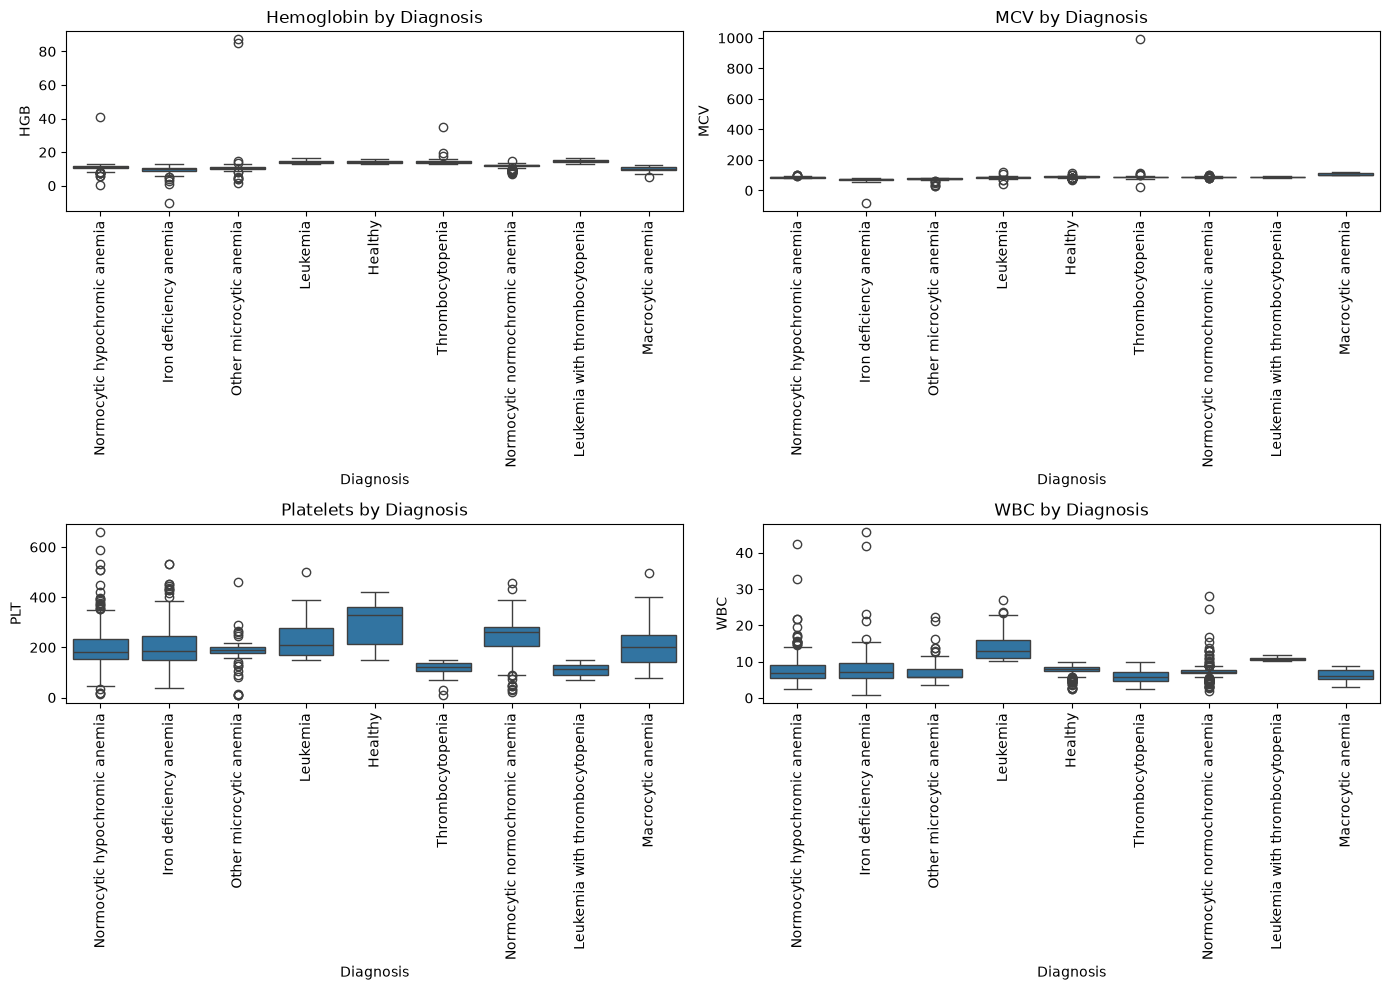

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='Diagnosis', y='HGB', ax=axes[0,0])
axes[0,0].set_title('Hemoglobin by Diagnosis')
axes[0,0].tick_params(axis='x', rotation=90)

sns.boxplot(data=df, x='Diagnosis', y='MCV', ax=axes[0,1])
axes[0,1].set_title('MCV by Diagnosis')
axes[0,1].tick_params(axis='x', rotation=90)

sns.boxplot(data=df, x='Diagnosis', y='PLT', ax=axes[1,0])
axes[1,0].set_title('Platelets by Diagnosis')
axes[1,0].tick_params(axis='x', rotation=90)

sns.boxplot(data=df, x='Diagnosis', y='WBC', ax=axes[1,1])
axes[1,1].set_title('WBC by Diagnosis')
axes[1,1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [8]:
df[['HGB', 'MCV']].describe()

,HGB,MCV
count,1281.000000,1281.000000
mean,12.184551,85.793919
std,3.812897,27.177663
min,-10.000000,-79.300000
25%,10.800000,81.200000
50%,12.300000,86.600000
75%,13.500000,90.200000
max,87.100000,990.000000


In [9]:
bad_hgb = df[(df['HGB'] < 3) | (df['HGB'] > 25)]
bad_mcv = df[(df['MCV'] < 40) | (df['MCV'] > 150)]

print(f"Bad HGB rows: {len(bad_hgb)}")
print(f"Bad MCV rows: {len(bad_mcv)}")
print(f"\nBad HGB values:\n{bad_hgb['HGB'].tolist()}")
print(f"\nBad MCV values:\n{bad_mcv['MCV'].tolist()}")

Bad HGB rows: 8
Bad MCV rows: 6

Bad HGB values:
[0.4, 1.2, 85.1, -10.0, 35.2, 87.1, 41.0, 1.8]

Bad MCV values:
[36.6, 31.3, -79.3, 990.0, 25.1, 30.3]


In [10]:
print(f"Rows before: {len(df)}")

df = df[(df['HGB'] >= 3) & (df['HGB'] <= 25)]
df = df[(df['MCV'] >= 40) & (df['MCV'] <= 150)]

print(f"Rows after: {len(df)}")

Rows before: 1281
Rows after: 1270


In [11]:
df.describe()

,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT
count,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000
mean,7.868378,25.809642,77.744087,1.881617,5.141003,4.650087,12.076134,46.038410,85.410323,32.100614,31.781457,230.849764,14.305691,0.251196
std,3.543685,6.940842,148.343618,1.336438,2.862615,2.525488,2.060940,105.046254,8.325890,111.641596,3.212095,92.570460,3.001612,0.591340
min,0.800000,6.200000,7.600000,0.200000,0.500000,1.360000,3.100000,10.100000,44.900000,11.400000,20.200000,10.000000,8.400000,0.010000
25%,6.000000,25.845000,71.400000,1.880760,5.140940,4.190000,10.800000,39.400000,81.325000,25.525000,30.600000,158.000000,13.300000,0.170000
50%,7.400000,25.845000,77.511000,1.880760,5.140940,4.600000,12.300000,46.152600,86.700000,27.800000,32.000000,214.000000,14.312512,0.260280
75%,8.680000,25.845000,77.511000,1.880760,5.140940,5.100000,13.500000,46.152600,90.200000,29.600000,32.900000,294.750000,14.600000,0.260280
max,45.700000,91.400000,5317.000000,41.800000,79.000000,90.800000,19.600000,3715.000000,124.100000,3117.000000,92.800000,660.000000,97.000000,13.600000


In [12]:
# Check how many rows share the exact same value (signs of imputation)
for col in ['LYMp', 'NEUTp', 'LYMn', 'NEUTn', 'HCT']:
    most_common_val = df[col].mode()[0]
    count_matching = (df[col] == most_common_val).sum()
    print(f"{col}: value {most_common_val} appears {count_matching} times ({count_matching/len(df)*100:.1f}%)")

LYMp: value 25.845 appears 781 times (61.5%)
NEUTp: value 77.511 appears 781 times (61.5%)
LYMn: value 1.88076 appears 781 times (61.5%)
NEUTn: value 5.14094 appears 781 times (61.5%)
HCT: value 46.1526 appears 781 times (61.5%)


In [13]:
imputed_value = df['LYMp'].mode()[0]
df['is_imputed'] = df['LYMp'] == imputed_value
pd.crosstab(df['Diagnosis'], df['is_imputed'])

is_imputed,False,True
Diagnosis,,
Healthy,51,285
Iron deficiency anemia,150,36
Leukemia,16,31
Leukemia with thrombocytopenia,10,1
Macrocytic anemia,3,15
Normocytic hypochromic anemia,168,109
Normocytic normochromic anemia,30,239
Other microcytic anemia,11,44
Thrombocytopenia,50,21


In [14]:
for col in ['LYMp', 'NEUTp', 'LYMn', 'NEUTn', 'HCT']:
    imputed_val = df[col].mode()[0]
    df[f'{col}_was_measured'] = (df[col] != imputed_val).astype(int)
    df.loc[df[col] == imputed_val, col] = None

df[['LYMp', 'LYMp_was_measured', 'NEUTp', 'NEUTp_was_measured']].head(10)

,LYMp,LYMp_was_measured,NEUTp,NEUTp_was_measured
0,43.2,1,50.1,1
1,42.4,1,52.3,1
2,30.7,1,60.7,1
3,30.2,1,63.5,1
5,27.3,1,65.4,1
6,19.1,1,68.2,1
7,27.4,1,64.0,1
8,19.7,1,72.4,1
9,12.4,1,79.0,1
10,35.6,1,56.9,1


In [15]:
df['LYMp_was_measured'].value_counts()

LYMp_was_measured
0    781
1    489
Name: count, dtype: int64

In [16]:
print(f"Rows before: {len(df)}")

df = df[(df['NEUTp'].isna()) | ((df['NEUTp'] >= 0) & (df['NEUTp'] <= 100))]
df = df[(df['HCT'].isna()) | ((df['HCT'] >= 10) & (df['HCT'] <= 65))]
df = df[(df['RBC'] >= 1) & (df['RBC'] <= 8)]

print(f"Rows after: {len(df)}")

Rows before: 1270
Rows after: 1265


In [17]:
df.to_csv('../data/processed/cbc_cleaned.csv', index=False)
print("Saved!")

Saved!


In [18]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Diagnosis', 'is_imputed'])
y = df['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")

Train: (1012, 19), Test: (253, 19)

Train class distribution:
Diagnosis
Healthy                           268
Normocytic hypochromic anemia     219
Normocytic normochromic anemia    215
Iron deficiency anemia            148
Thrombocytopenia                   57
Other microcytic anemia            44
Leukemia                           38
Macrocytic anemia                  14
Leukemia with thrombocytopenia      9
Name: count, dtype: int64


In [19]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test), 
    columns=X_test.columns, 
    index=X_test.index
)

print("Missing values in train after imputation:", X_train_imputed.isna().sum().sum())
print("Missing values in test after imputation:", X_test_imputed.isna().sum().sum())

Missing values in train after imputation: 0
Missing values in test after imputation: 0


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train_imputed, y_train)

y_pred = rf.predict(X_test_imputed)

print(classification_report(y_test, y_pred))

                                precision    recall  f1-score   support

                       Healthy       1.00      1.00      1.00        67
        Iron deficiency anemia       1.00      0.97      0.99        37
                      Leukemia       1.00      1.00      1.00         9
Leukemia with thrombocytopenia       0.67      1.00      0.80         2
             Macrocytic anemia       1.00      1.00      1.00         4
 Normocytic hypochromic anemia       1.00      1.00      1.00        55
Normocytic normochromic anemia       1.00      1.00      1.00        54
       Other microcytic anemia       0.92      1.00      0.96        11
              Thrombocytopenia       1.00      0.93      0.96        14

                      accuracy                           0.99       253
                     macro avg       0.95      0.99      0.97       253
                  weighted avg       0.99      0.99      0.99       253



In [21]:
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=X_train_imputed.columns)
importances.sort_values(ascending=False)

MCV                   0.168323
HGB                   0.143686
WBC                   0.117236
PLT                   0.105696
MCH                   0.105193
MCHC                  0.095548
RBC                   0.077012
NEUTn                 0.037127
PCT                   0.035934
HCT                   0.029252
LYMp                  0.018117
PDW                   0.010636
NEUTp                 0.010406
LYMn                  0.009614
NEUTn_was_measured    0.009438
NEUTp_was_measured    0.008412
LYMp_was_measured     0.006214
HCT_was_measured      0.006201
LYMn_was_measured     0.005956
dtype: float64

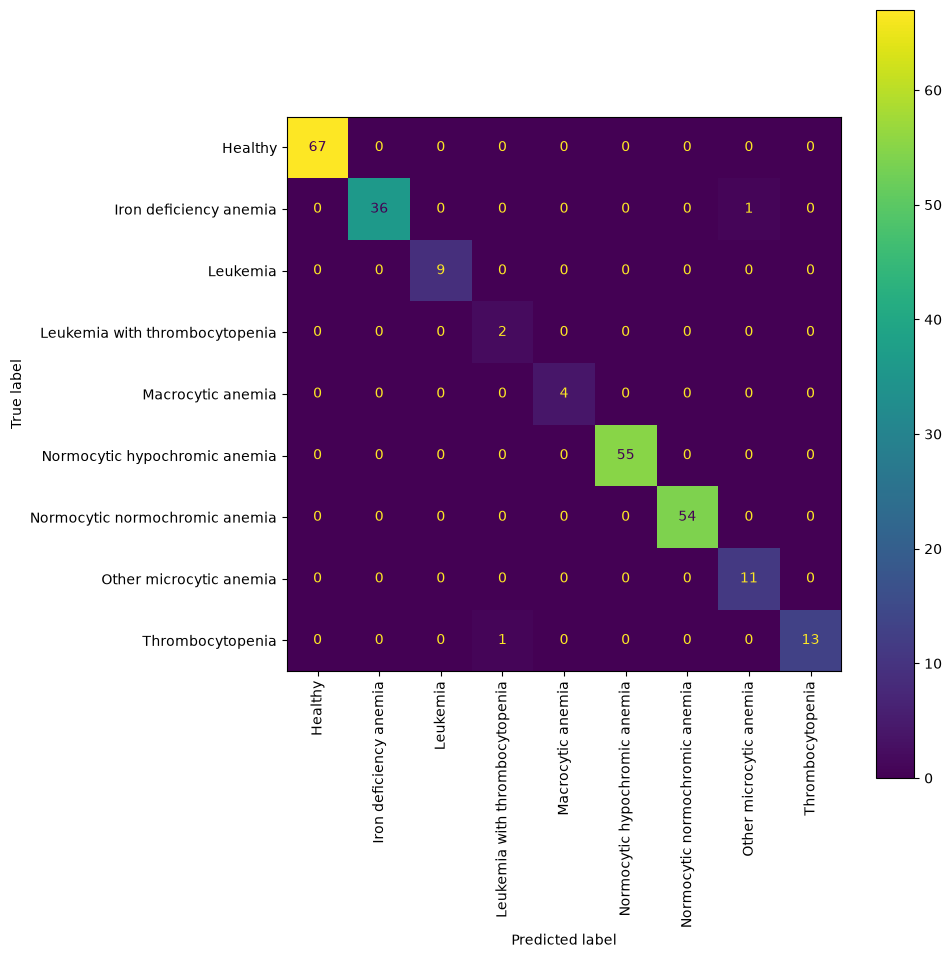

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, xticks_rotation=90)
plt.tight_layout()
plt.show()

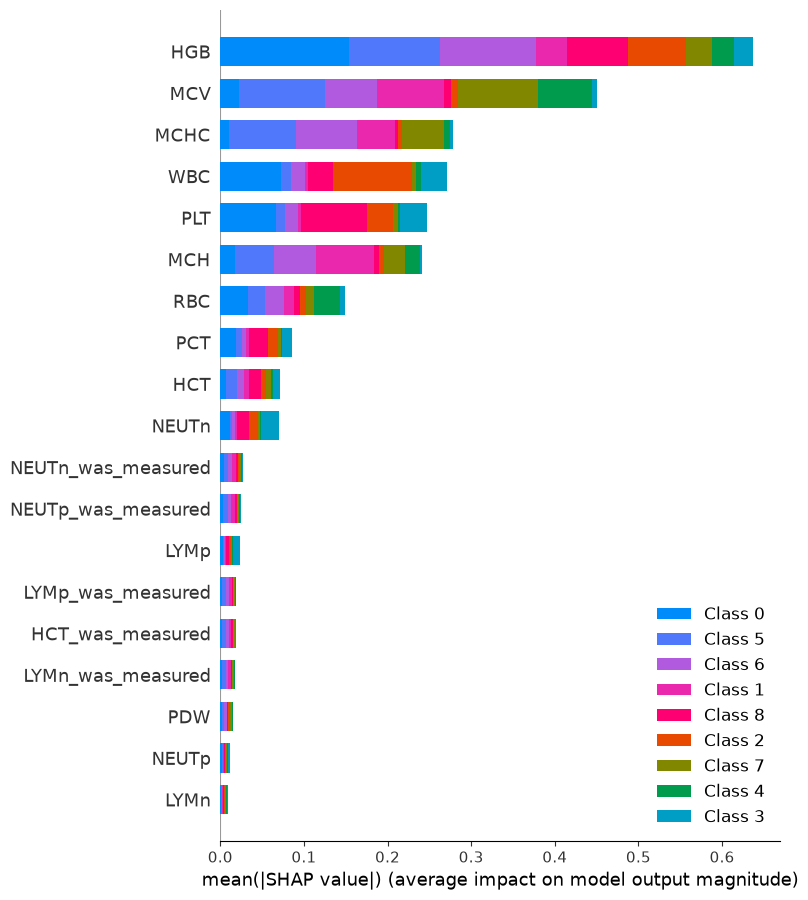

In [23]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_imputed)

shap.summary_plot(shap_values, X_test_imputed, plot_type='bar')

In [24]:
import numpy as np

np.random.seed(42)
noise_level = 0.05  # 5% random noise relative to each feature's typical spread

X_test_noisy = X_test_imputed.copy()
for col in X_test_noisy.columns:
    if 'was_measured' not in col:
        std = X_train_imputed[col].std()
        noise = np.random.normal(0, std * noise_level, size=len(X_test_noisy))
        X_test_noisy[col] = X_test_noisy[col] + noise

y_pred_noisy = rf.predict(X_test_noisy)
print(classification_report(y_test, y_pred_noisy))

                                precision    recall  f1-score   support

                       Healthy       0.98      0.91      0.95        67
        Iron deficiency anemia       0.92      0.89      0.90        37
                      Leukemia       1.00      1.00      1.00         9
Leukemia with thrombocytopenia       0.67      1.00      0.80         2
             Macrocytic anemia       1.00      1.00      1.00         4
 Normocytic hypochromic anemia       0.74      0.95      0.83        55
Normocytic normochromic anemia       0.97      0.72      0.83        54
       Other microcytic anemia       0.77      0.91      0.83        11
              Thrombocytopenia       0.81      0.93      0.87        14

                      accuracy                           0.88       253
                     macro avg       0.87      0.92      0.89       253
                  weighted avg       0.90      0.88      0.88       253

